In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error ,mean_absolute_error, r2_score

In [17]:
df=pd.read_csv('salary_experience.csv')
df

,experience_years,salary_k
0,6.088383,193.657709
1,7.109371,206.521482
2,4.036323,134.513228
3,9.143522,270.084944
4,8.196867,240.073159
...,...,...
995,17.145433,453.254885
996,19.385876,507.022031
997,17.724494,473.990924
998,1.652201,75.688656


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   experience_years  1000 non-null   float64
 1   salary_k          1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [19]:
df.describe()

,experience_years,salary_k
count,1000.000000,1000.000000
mean,9.746703,273.777822
std,5.696114,142.474744
min,0.009819,19.125108
25%,4.895444,152.412764
50%,9.662240,271.575043
75%,14.658549,395.954741
max,19.999132,536.083771


In [20]:
df['experience_years'].median()

9.662240242993501

In [21]:
df['experience_years'].skew()

np.float64(0.03801531098802497)

In [22]:
df.isnull().sum()

experience_years    0
salary_k            0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
X=df[['experience_years']]
y=df['salary_k']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [25]:
predictions = model.predict(X_test)

In [26]:
r2_score = model.score(X_test, y_test)
r2_score

0.9987678957991076

In [27]:
mae = mean_absolute_error(y_test, predictions)
mae

4.105862886585085

In [28]:
mse = mean_squared_error(y_test, predictions)
mse

25.62698622308543

In [29]:
rmse = np.sqrt(mse)
rmse

np.float64(5.062310364160363)

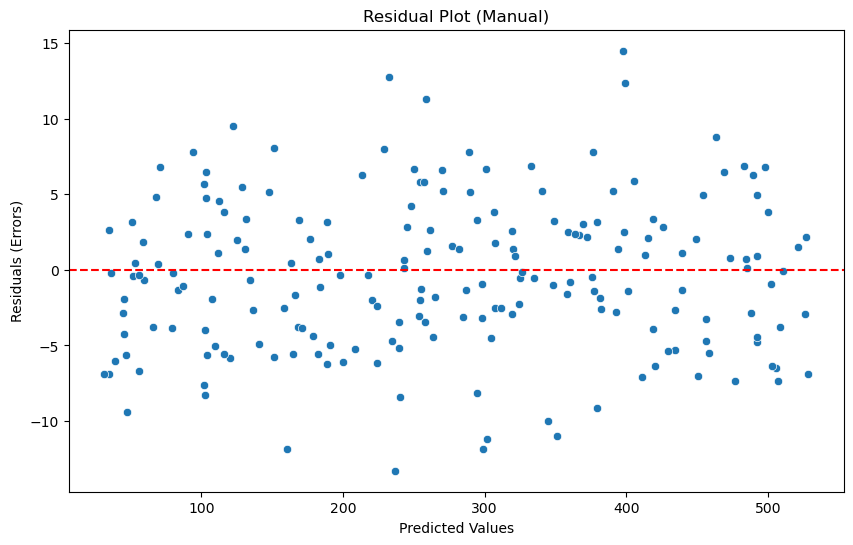

In [30]:
import seaborn as sns
residuals = y_test - predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Manual)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.show()